## ** Import the All Libraries + Using Pip to install the Library **

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib


In [ ]:
pip install missingno

In [ ]:
import missingno as msno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Create a formatted table of versions
versions = pd.DataFrame({
    "Library" : ["NumPy", "Pandas", "Matplotlib", "Seaborn", "Missingno"],
    "Version" : [
        np.__version__,
        pd.__version__,
        matplotlib.__version__,
        sns.__version__,
        msno.__version__
    ]
})

# Display the table
print("Library Versions:\n")
print(versions.to_string(index=False))

Library Versions:

   Library Version
     NumPy   2.0.2
    Pandas   2.2.2
Matplotlib  3.10.0
   Seaborn  0.13.2
 Missingno   0.5.2


**Add the Titanic Data set **


# Step # 01: Numppy (Broadcasting & Making)

In [ ]:
# part a
scores = np.random.randint(0,101, size=(6,4))
print(" (a) Original Scores Matrix (6 students × 4 exams):\n")
print(scores)

# part b
col_min = scores.min(axis=0)
col_max = scores.max(axis=0)
nor = (scores - col_min) / (col_max - col_min)
print("\n (b) Column-wise Normalized Matrix [0,1]:\n")
print(nor)

# part # c Create boolean mask for students averaging >= 60
average = scores.mean(axis = 1)
mask = average >= 60
pass_student = scores[mask]
print("\n (c) Student Averages:\n", average)
print("\n Passing Mask (>= 60):\n", mask)
print("\n Passing Students:\n")
print(pass_student)

# part # d
col_mean = scores.mean(axis=0)
adj_score = np.where(scores < 4, col_mean, scores)
print("\n (d) Column Means:\n", col_mean)
print("\n Scores after replacing values < 40:\n")
print(adj_score)

#part # e

Weight = np.random.rand(4)
wei_scores = nor.dot(Weight)
print("\n (e) Random Weight Vector:\n", Weight)
print("\n Weighted Scores (Dot Product Result):\n")
print(Weight)



 (a) Original Scores Matrix (6 students × 4 exams):

[[15 94 78 13]
 [68 61 53 88]
 [57 15 56 91]
 [14 86  4 82]
 [14  5  4 29]
 [32 27  6 93]]

 (b) Column-wise Normalized Matrix [0,1]:

[[0.01851852 1.         1.         0.        ]
 [1.         0.62921348 0.66216216 0.9375    ]
 [0.7962963  0.11235955 0.7027027  0.975     ]
 [0.         0.91011236 0.         0.8625    ]
 [0.         0.         0.         0.2       ]
 [0.33333333 0.24719101 0.02702703 1.        ]]

 (c) Student Averages:
 [50.   67.5  54.75 46.5  13.   39.5 ]

 Passing Mask (>= 60):
 [False  True False False False False]

 Passing Students:

[[68 61 53 88]]

 (d) Column Means:
 [33.33333333 48.         33.5        66.        ]

 Scores after replacing values < 40:

[[15. 94. 78. 13.]
 [68. 61. 53. 88.]
 [57. 15. 56. 91.]
 [14. 86.  4. 82.]
 [14.  5.  4. 29.]
 [32. 27.  6. 93.]]

 (e) Random Weight Vector:
 [0.0397201  0.98579931 0.40299612 0.61262637]

 Weighted Scores (Dot Product Result):

[0.0397201  0.98579931 0.

# Step # 02: Load Data set and Inspection

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train (1).csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.sample(8, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
before_dtypes = df.dtypes
before_dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# no of categorical col
cat_cols = df.select_dtypes(include='object').shape[1]
cat_cols

5

In [ ]:
# no of the numberical col
num_cols = df.select_dtypes(include='number').shape[1]
num_cols

7

In [ ]:
# Columns with missing values
cols_missing_val = df.columns[df.isnull().any()].tolist()
print(cols_missing_val)
len(cols_missing_val)

['Age', 'Cabin', 'Embarked']


3

In [ ]:
# total missing value
Total_missing_val = df.isnull().sum()
Total_missing_val


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Step # 03: Missing Value Deep Analysis

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


<Axes: >

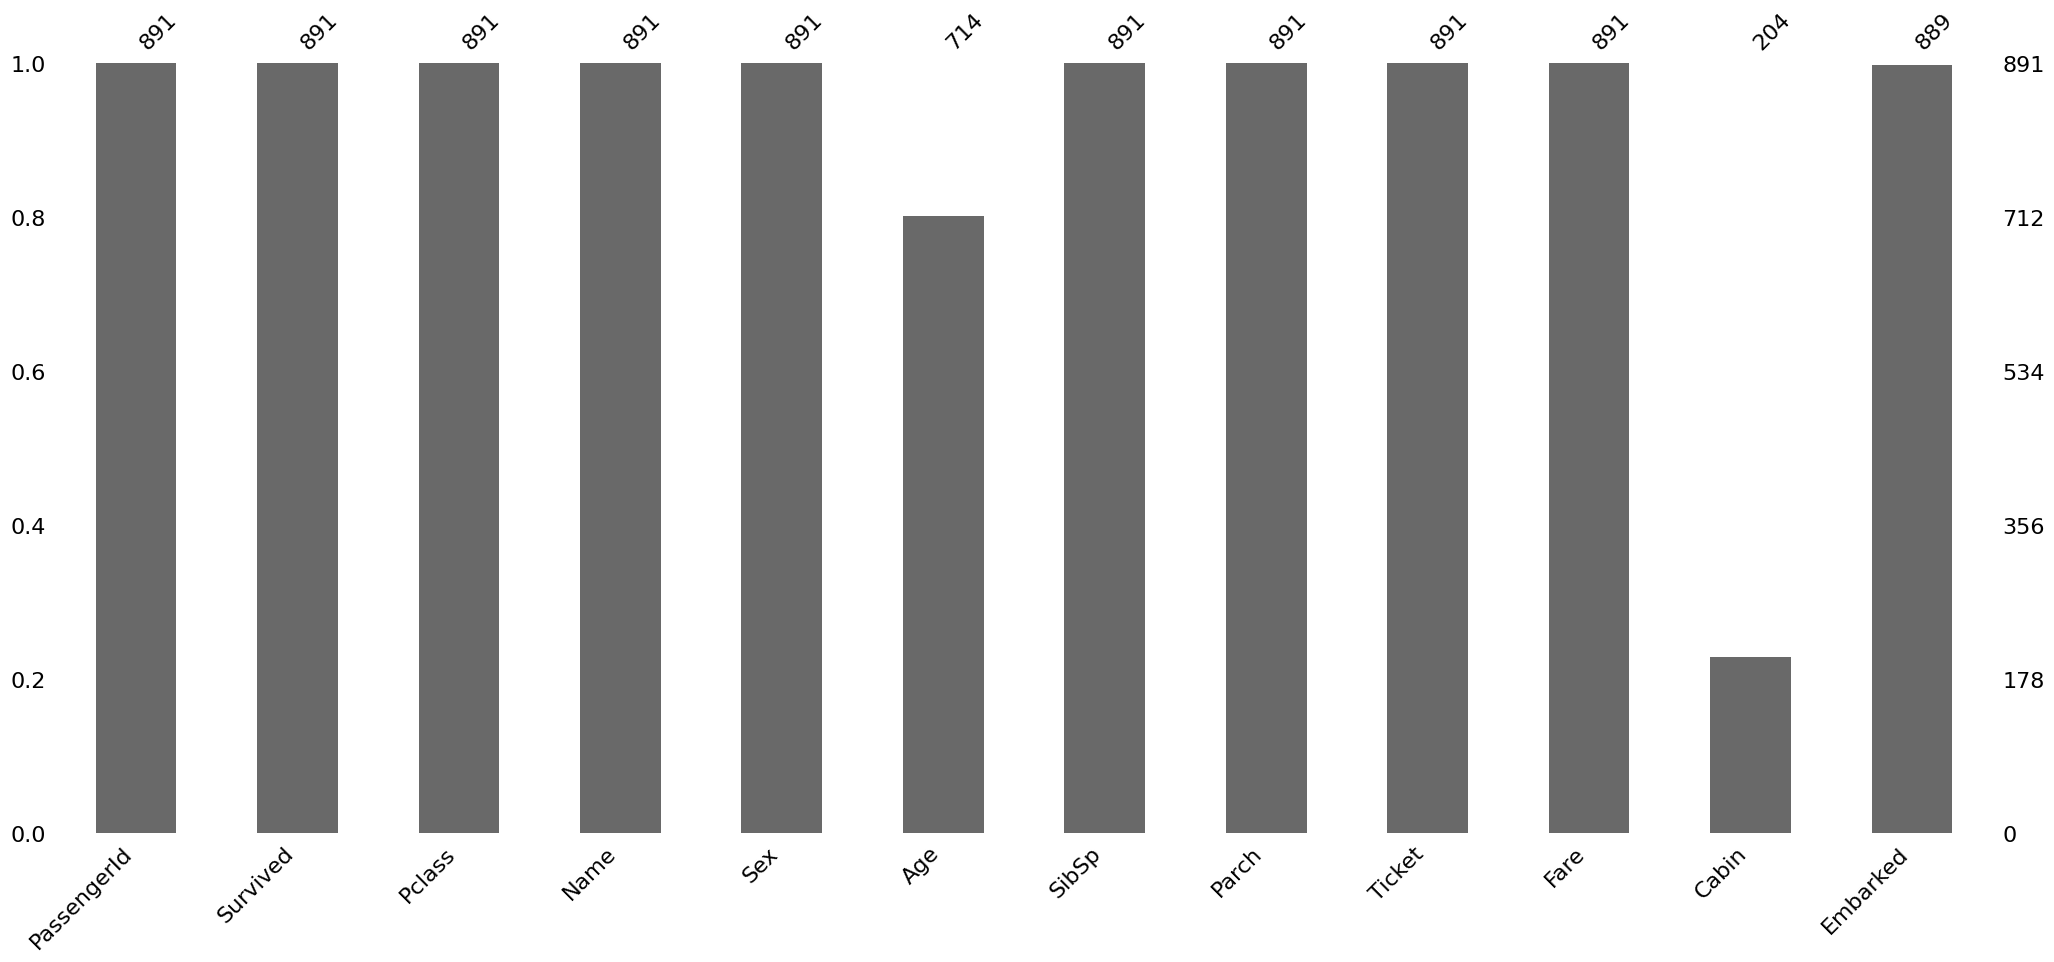

In [ ]:
msno.bar(df)


Column 1: Cabin
(a) Why missing?
In real ship data, many passengers did not have recorded cabin numbers
Lower-class passengers often did not have assigned cabins
Records may have been lost
(b) Best strategy:

Reason:
Too many missing values (~70%+), so it is unreliable.
📝 Column 2: Age
(a) Why missing?
Passenger age was not always recorded
Some records incomplete or unknown at time of boarding
(b) Best strategy:

✔ Fill using median age

df["Age"].fillna(df["Age"].median(), inplace=True)

✔ OR better: add missing flag

df["Age_missing"] = df["Age"].isnull().astype(int)
📝 Column 3: Embarked
(a) Why missing?
A few passengers boarded without proper documentation
Data entry error or missing record
(b) Best strategy:

✔ Fill with mode (most common value)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Step # 04: Data Type Audit & Correction

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
df["Fare"] = pd.to_numeric(df["Fare"], errors='coerce')
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

In [ ]:
# Convert 'Survived' and 'Pclass' to category dtype
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

#  Why convert Survived?
It is NOT numeric.  
It is a label (0 = No, 1 = Yes).      
Used for classification, not calculation
#  Why convert Pclass?
Represents groups (1st, 2nd, 3rd class).       
Not a continuous number.                
Better treated as categories.        

In [ ]:
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,category
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# BEFORE vs AFTER comparison table
comparison = pd.DataFrame({
    "Column": df.columns,
    "New_Dtype": df.dtypes.values,
    "Old_Dtype": before_dtypes
})
comparison

,Column,New_Dtype,Old_Dtype
PassengerId,PassengerId,int64,int64
Survived,Survived,category,int64
Pclass,Pclass,category,int64
Name,Name,object,object
Sex,Sex,category,object
Age,Age,float64,float64
SibSp,SibSp,int64,int64
Parch,Parch,int64,int64
Ticket,Ticket,object,object
Fare,Fare,float64,float64


# Part B -  DATA CLEANING & FEATURE ENGINEERING


# Step # 05: Handle Missing Values — Professional Strategy

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


In [ ]:
# filing the missing value in the age column using median
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print(df['Age'])

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    21.5
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


**Why NOT use global mean?**                        
The mean is sensitive to outliers (extremely high/low ages can distort it).
It ignores passenger differences (e.g., children in 3rd class vs adults in 1st class).       
**Why group-level median is better:**             
Captures real patterns: Age distribution differs by class and gender.
More accurate imputation: A female in 1st class likely has a different age profile than a male in 3rd class.
Median is robust: Not affected by outliers.

In short: more realistic + more stable = better model

In [ ]:
# Handle the Embaraked missing values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     891 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


In [ ]:
# Handle ‘Cabin’
df['has_cabin'] = df['Cabin'].notnull().astype(int)

# drop the original col
df.drop('Cabin', axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  has_cabin    891 non-null    int64   
dtypes: category(4), float64(2), int64(4), object(2)
memory usage: 59.8+ KB


In [ ]:
# after all cleaning the dataset then check the null values
print(df.isnull().sum().sum())

0


In [ ]:
# summary
print("Age → Filled using median grouped by Pclass & Sex (robust and more realistic than global mean)")
print("Embarked → Filled using mode (most frequent category)")
print("Cabin → Created 'has_cabin' feature (1/0) and dropped original column due to high missingness")

Age → Filled using median grouped by Pclass & Sex (robust and more realistic than global mean)
Embarked → Filled using mode (most frequent category)
Cabin → Created 'has_cabin' feature (1/0) and dropped original column due to high missingness


# Step # 06: Outlier Detection & Treatment

In [ ]:
# a - Compute IQR and Fences
#for Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)

IQR = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR
upper_fare = Q3_fare + 1.5 * IQR

# for age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)

IQR_age = Q3_age = Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age



In [ ]:
# b - Identify value outside fence
fare_outliers = df[(df['Fare'] < lower_fare) | (df['Fare'] > upper_fare)].shape[0]
age_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)].shape[0]

print(" Fare outliers :", fare_outliers)
print(" Age outliers : ", age_outliers)

 Fare outliers : 116
 Age outliers :  50


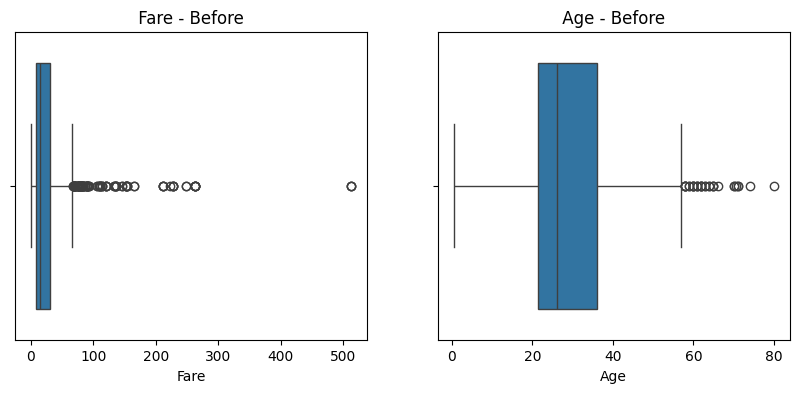

In [ ]:
# c - box plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.boxplot(x=df['Fare'])
plt.title(" Fare - Before ")

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])
plt.title(" Age - Before ")

plt.show()


In [ ]:
# d - Treat Fare Outliers (Capping at 99th Percentile)
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)

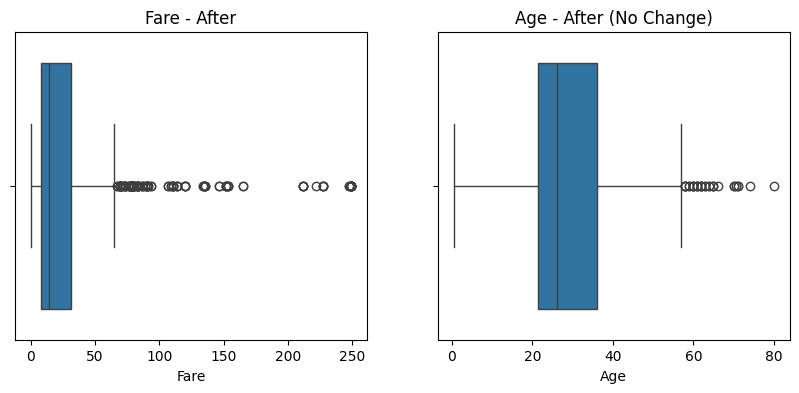

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Fare'])
plt.title("Fare - After")

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])
plt.title("Age - After (No Change)")

plt.show()

In [ ]:
# e - Age Treatment Decision
print(" Age Min : ", df['Age'].min())
print(" Age Max : ", df['Age'].max())

 Age Min :  0.42
 Age Max :  80.0


## Outlier Treatment Decisions

- **Fare**:
  - Extreme high values detected (mostly first-class passengers).
  - These are real observations, not errors.
  - Applied **capping at 99th percentile** to reduce skewness without losing data.

- **Age**:
  - Outliers fall within a realistic human age range.
  - No extreme or incorrect values found.
  - Therefore, **no treatment applied**.

---

## Why Winsorization (Capping) is Better Than Dropping Outliers?

- Dropping removes valuable data → reduces dataset size.
- In small datasets (like Titanic), this can hurt model performance.
- Outliers may represent **important real-world cases** (e.g., wealthy passengers).
- Capping keeps all rows but **limits extreme influence**.
- Leads to **more stable and robust machine learning models**.

# Step # 07: Feature Engineering

In [ ]:
# a - family size
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['family_size']

,family_size
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


In [ ]:
# b - along family member
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['is_alone']

,is_alone
0,0
1,0
2,1
3,0
4,1
...,...
886,1
887,1
888,0
889,1


In [ ]:
# c - fare per person
df['fare_per_person'] = df['Fare']/df['family_size']
df['fare_per_person']

,fare_per_person
0,3.62500
1,35.64165
2,7.92500
3,26.55000
4,8.05000
...,...
886,13.00000
887,30.00000
888,5.86250
889,30.00000


In [ ]:
# d - title match
df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = df['title'].value_counts()[df['title'].value_counts() < 10].index
df['title'] = df['title'].replace(rare_titles, 'Rare')
df['title']

,title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rare
887,Miss
888,Miss
889,Mr


In [ ]:
# e - age represent
df['age_group'] = pd.cut(df['Age'],
                         bins=[0,12,18,60,100],
                         labels=['Child','Teen','Adult','Senior'])
df['age_group'].sample(6)

,age_group
93,Adult
505,Teen
449,Adult
229,Adult
697,Adult
816,Adult


In [ ]:
# f - extract letter of of first cabin
# No deck feature possible since Cabin column is dropped , then replace with has_cabin
print("Deck feature skipped: Cabin column was removed earlier.")

df.info()

Deck feature skipped: Cabin column was removed earlier.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    category
 2   Pclass           891 non-null    category
 3   Name             891 non-null    object  
 4   Sex              891 non-null    category
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Embarked         891 non-null    category
 11  has_cabin        891 non-null    int64   
 12  family_size      891 non-null    int64   
 13  is_alone         891 non-null    int64   
 14  fare_per_person  891 non-null    float64 
 15  title            891 non-null    ob

In [ ]:
# g - fare bin
df['fare_bin'] = pd.qcut(df['Fare'],
                        q=4,
                        labels=['Low', 'Medium', 'High', 'VHigh'])
df['fare_bin'].sample(5)

,fare_bin
697,Low
302,Low
215,VHigh
849,VHigh
526,Medium


In [ ]:
# Show First 10 Rows (All 7 Features)
print(df[['family_size', 'is_alone', 'fare_per_person',
          'title', 'age_group', 'fare_bin']].head(10))

   family_size  is_alone  fare_per_person   title age_group fare_bin
0            2         0          3.62500      Mr     Adult      Low
1            2         0         35.64165     Mrs     Adult    VHigh
2            1         1          7.92500    Miss     Adult   Medium
3            2         0         26.55000     Mrs     Adult    VHigh
4            1         1          8.05000      Mr     Adult   Medium
5            1         1          8.45830      Mr     Adult   Medium
6            1         1         51.86250      Mr     Adult    VHigh
7            5         0          4.21500  Master     Child     High
8            3         0          3.71110     Mrs     Adult   Medium
9            2         0         15.03540     Mrs      Teen     High


# Step # 08: Encoding Categorical Variables  